# Assortativity (Asortatividad)
**Tendencia de nodos a conectarse con otros nodos similares en lugar de con nodos no similares.**
- Dos nodos son similares con respecto a una propiedad si tienen el mismo valor para esa propiedad.
    - Estas propiedades pueden ser cualquier propiedad estructural como el grado de un nodo y otras como el peso o la capacidad
    - Con estas propiedades se puede determinar una medida de asortatividad para la red. 
    - Disasortatividad si los nodos prefieren conectarse a no similares antes que similares
## Coeficientes de asortatividad
Sea una red $N = (V, E)$ con $V$ el conjunto de vértices en la red y $E$ el conjunto de aristas en la red. Téngase $P(v)$ que representa una propiedad $\forall v$ 

### Matriz de mezcla
Tome la propiedad $P(v)$ $P[0], P[1],\ldots P[k-1]$ valores distintos en la red, entonces la **matriz de mezcla** es la matriz $M$ donde $M[i][j]$ representa el número de aristas desde nodos con la propiedad $P[i]$ hacia $P[j]$. Aunque en redes no dirigidas no hay relación de ***desde/hacia***, solo son la cantidad de aristas que conectan nodos con esas propiedades.

**NOTA:** Se puede normalizar la matriz de mezcla dividiéndola entre el número total de aristas ordenados tal que $e = \frac{M}{|E|}$. Normalizar significa transformar la matriz de números enteros a una de probabilidades donde cada celda ahora representa la proporción de esa conexión respecto al total de la red. Entonces la suma de todas las celdas da 1. Así se puede por ejemplo comparar correctamente la asortatividad de dos redes porque no es lo mismo haya 40 aristas en una red con 100 aristas que 40 aristas en una red de 100K.

Se define,
- $a[i]$ como la proporción de aristas $(u,v)$ donde $P(u) = P[i]$ tal que $$a[i] = \sum_j e[i][j]$$. Es decir, la prob de que el vértice de origen $u$ tenga la prop $P[i]$. Total de enlaces que salen de vértices tipo $i$.
- $b[i]$ como la proporción de aristas $(u,v)$ donde $P(v) = P[i]$ tal que $$b[i] = \sum_j e[j][i]$$. Es decir, la prob de que el vértice de destino $v$ tenga la prop. Total de enlaces que llegan en nodos tipo $i$.
- $\sigma_a$ y $\sigma_b$ representan la desviación estandar de $\{P[i] \cdot a[i] | i \in 0 \ldots k -1\}$ y $\{P[i] \cdot b[i] | i \in 0 \ldots k -1\}$, respectivamente. Si todos los vértices tienen casi el mismo grado o la misma propiedad, la desviación se acerca a 0.

Con esto se define el coeficiente de asortatividad para esta propiedad basado en el coeficiente de correlación de Pearson.
- Coeficiente de asortatividad en atributos (con $P(v)$ una propiedad nominal asignada a cada nodo.
$$ r = \frac{\sum_i e_{ii} - \sum_i a_i b_i}{1 - \sum_i a_i b_i} = \frac{Trace(e)-||e^2||}{1-||e^2||}$$
Esto está implementado como ***attribute_assortativity_coefficient***.
- Coeficiente de asortatividad numérica (con $P(v)$ una propiedad numérica asignada a cada nodo.
$$ r = \frac{\sum_{ij} P_i P_j(e_{ij}-a_i b_j)}{\sigma_a \sigma_b}$$
- Coefienciente de asortatividad de grado:
    - Existen dos tipos de grados: **de entrada** y **de salida**. Por ende se pueden tener cuatro tipos de asortatividad de grado. De nuevo, si la red no es dirigida, todos los grados son iguales. Aqui copio el texto:
        - r(in,in) : Measures tendency of having a directed edge (u,v) such that, in-degree(u) = in-degree(v). Los nodos que reciben muchos enlaces tienden a apuntar a otros que recbien muchos también?
        - r(in,out) : Measures tendency of having a directed edge (u,v) such that, in-degree(u) = out-degree(v). ... apuntan a nodos que emiten muchos enlaces?
        - r(out,in) : Measures tendency of having a directed edge (u,v) such that, out-degree(u) = in-degree(v). Los que emiten muchos enlaces apuntan a nodos que reciben muchos?
        - r(out,out) : Measures tendency of having a directed edge (u,v) such that, out-degree(u) = out-degree(v). Los grandes emisores apuntan únicamente a otros grandes emisores?

Sea $x,y \in \{in, out\}$, $e_{ij}$ la proporción de aristas dirigidos $(u,v)$ con $x\text{-degree}(u) = P_i$ y $y\text{-degree}(v) = P_j$ entonces:

$$ r(x,y) = \frac{\sum_{ij} P_i P_j(e_{ij} - a_i b_j)}{\sigma_a \sigma_b}$$

Implementado como `degree_assortativity_coefficient` y `degree_pearson_correlation_coefficient`, siendo la última más rápida.


In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import copy
import random
import warnings

%matplotlib inline

In [9]:
# para hacer esto es necesario haber visto el notebook "basico.ipynb"
gname = "g2"
G = nx.read_graphml(f"data/{gname}.graphml") #serializar archivo con formato especial que tiene toda la info del grafo
with open(f"data/pos_{gname}", "rb") as fp: # abre como binario. rb es read binary.
    pos = pickle.load(fp) # pickle es una herramienta para seralización de objetos. Recontruye en memoria el objeto que le pasamos

C:\Users\juanf\miniconda3\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:302: RuntimeWarning: invalid value encountered in scalar divide
  return float((xy * (M - ab)).sum() / np.sqrt(vara * varb))


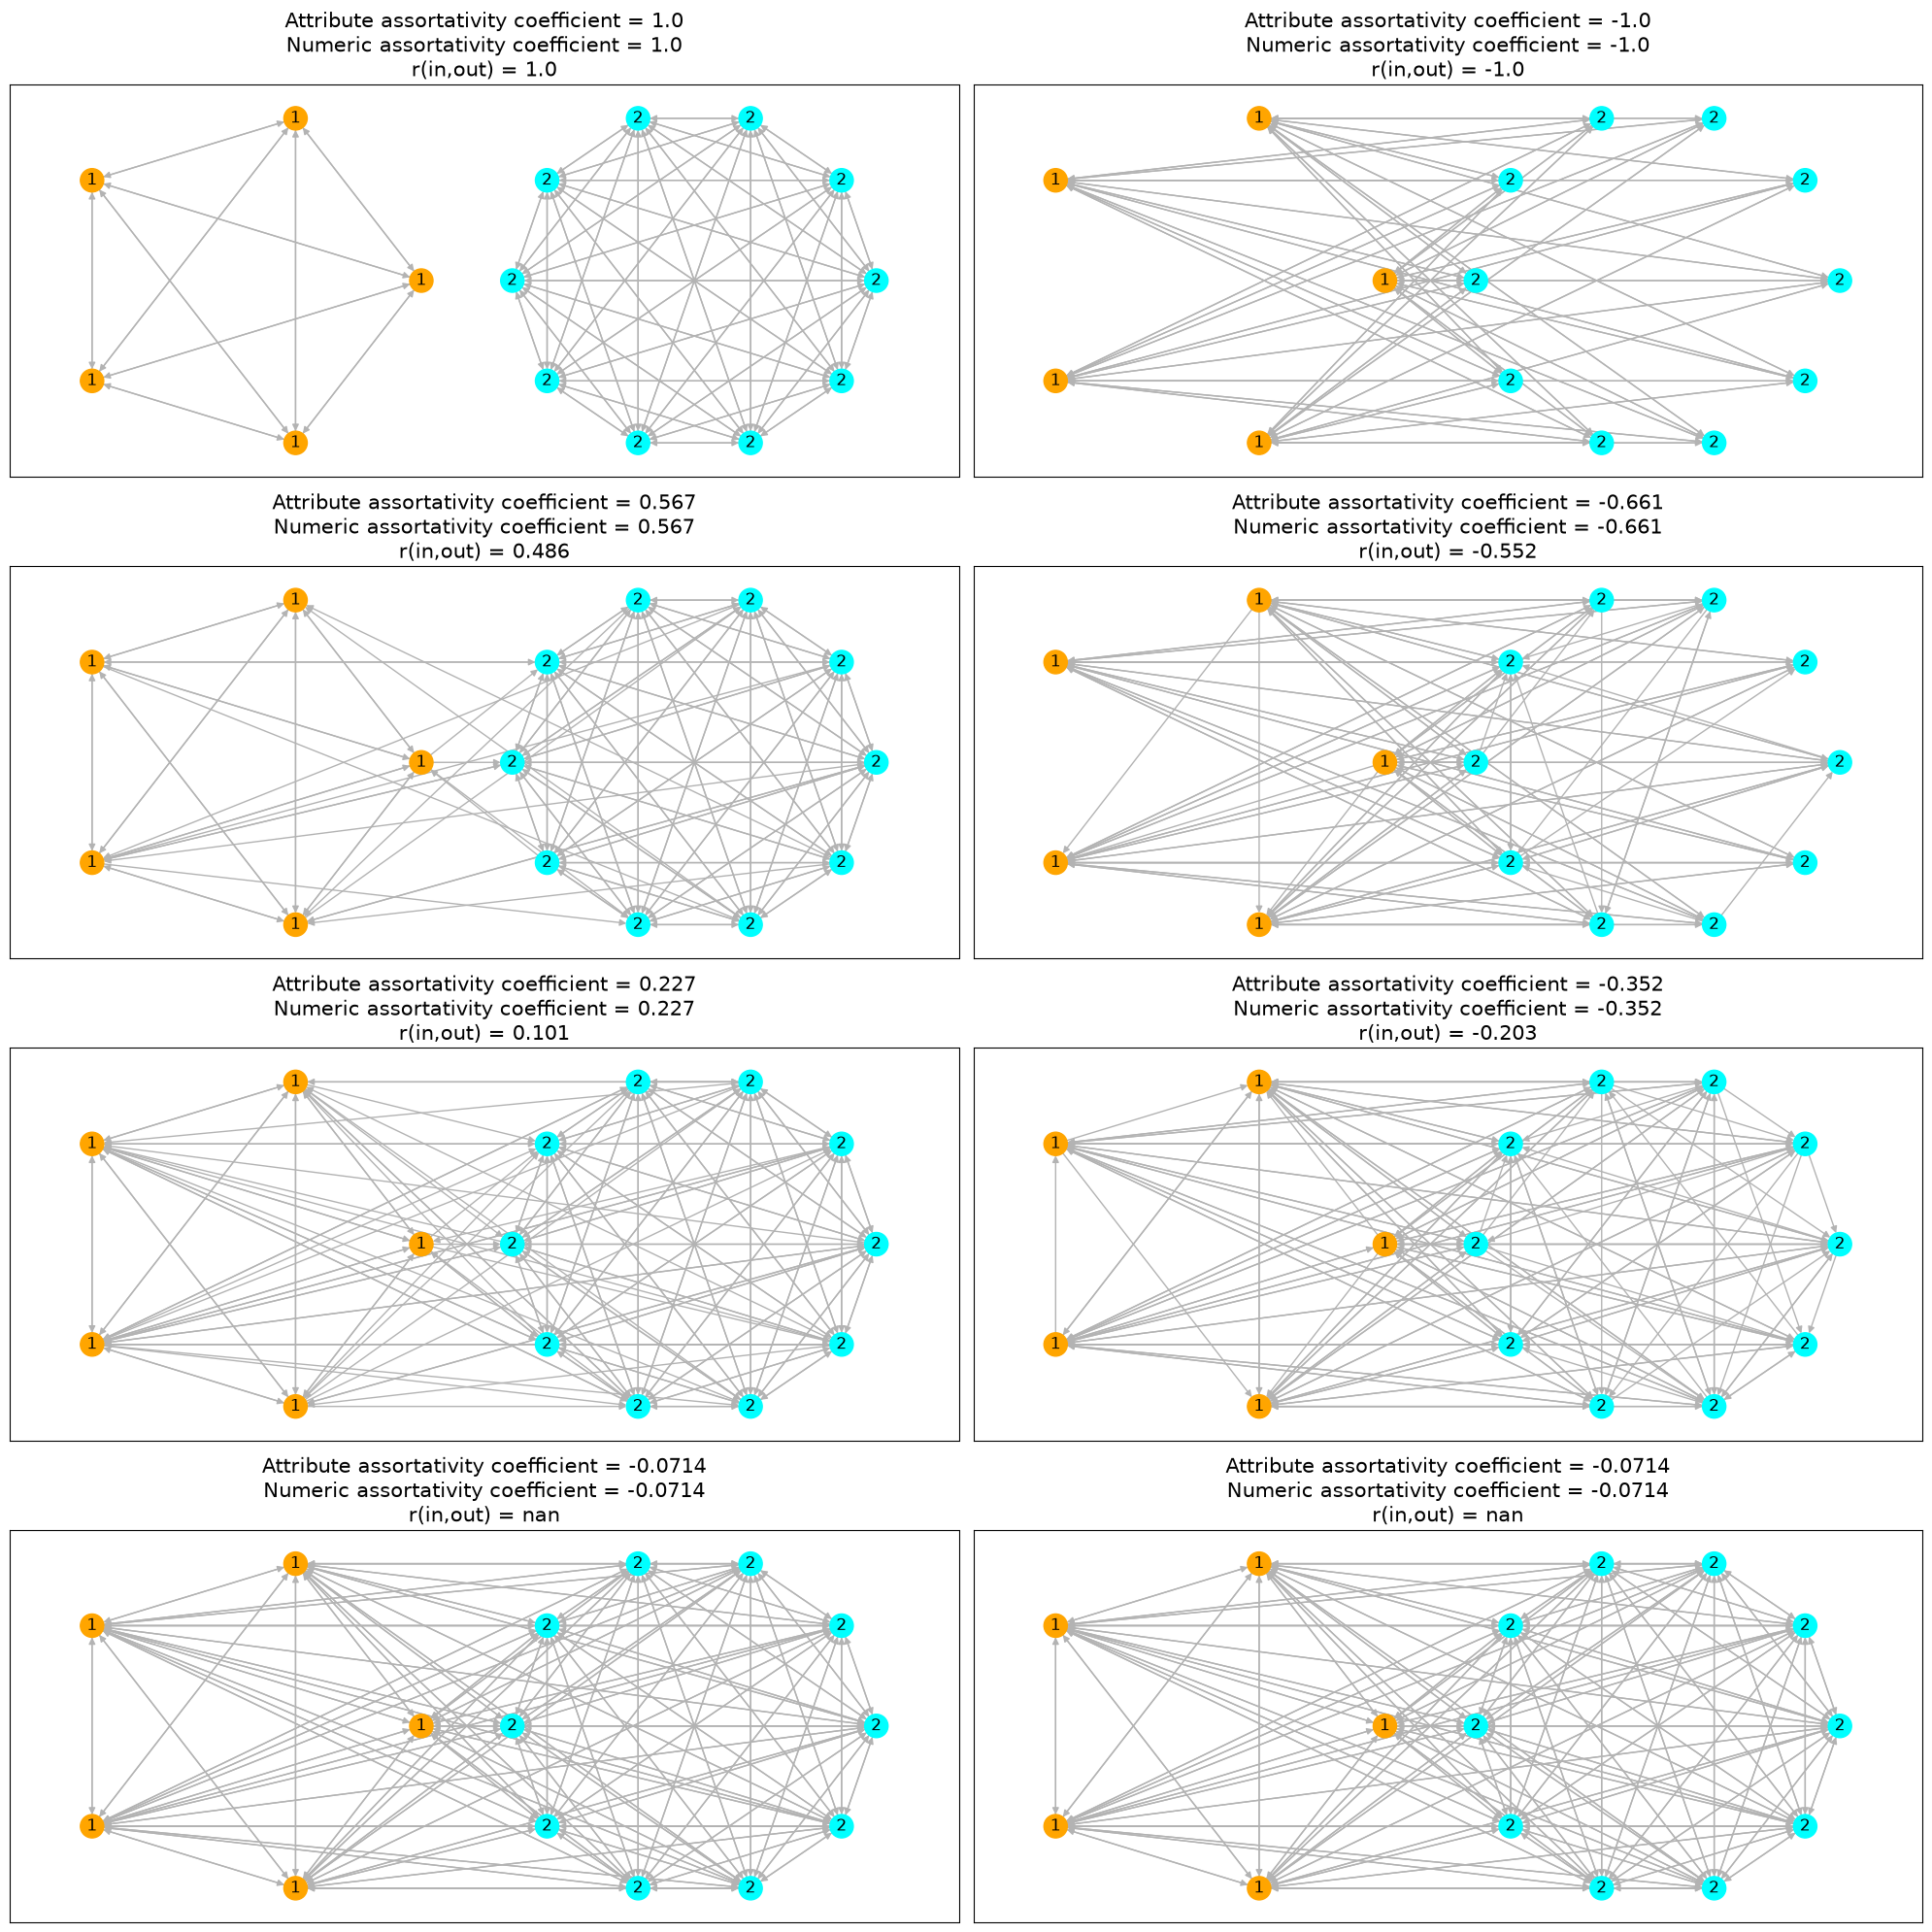

In [10]:
fig, axes = plt.subplots(4,2, figsize=(20,20)) #linezo de matlotlib con 4 filas, 2 columnas, tamaño de 20x20
# asignar colores y labels a nodos basado en sus clusters y propiedad num_prop
node_colors = ["orange" if G.nodes[u]["cluster"] == "K5" else "cyan" for u in G.nodes] #sintaxis rara de python para crear un arreglo de colores según si el metadadto del nodo en "cluseter" dice K5 entonces naranja.
node_labels = {u: G.nodes[u]["num_prop"] for u in G.nodes} #... para crear un hashmap donde cada key es el id de nodo u y value es el metadato num_prop 

for i in range(8):
    g = nx.read_graphml(f"data/{gname}_{i}.graphml") #diferentes estados o evoluciones de la red
    
    #calcular coeficientes de asortatividad con respecto a diferentes propieadades
    cr = nx.attribute_assortativity_coefficient(g, "cluster") #asortatividad nominal basada en atributo "cluster"
    r_in_out = nx.degree_assortativity_coefficient(g, x="in", y="out") #asortatividad estructural de grado. tendencia de nodos con alto grado in a conectarse con nodos de alto grado out
    nr = nx.numeric_assortativity_coefficient(g, "num_prop") #asortatividad numérica con propiead num_prop
    
    # dibujar red
    
    nx.draw_networkx_nodes(
        g, pos=pos, node_size=300, ax=axes[i // 2][i % 2], node_color=node_colors
    )
    
    nx.draw_networkx_labels(g, pos=pos, labels=node_labels, ax=axes[i //2][i %2])
    
    nx.draw_networkx_edges(g, pos=pos, ax=axes[i // 2][i %2], edge_color="0.7")
    axes[i //2][i %2].set_title(
        f"Attribute assortativity coefficient = {cr:.3}\nNumeric assortativity coefficient = {nr:.3}\nr(in,out) = {r_in_out:.3}",
        size=15,
    )
    
    fig.tight_layout()
    #El error que sale abajo incluso sale en el tutorial

C:\Users\juanf\miniconda3\Lib\site-packages\networkx\algorithms\assortativity\correlation.py:282: RuntimeWarning: invalid value encountered in scalar divide
  r = (t - s) / (1 - s)


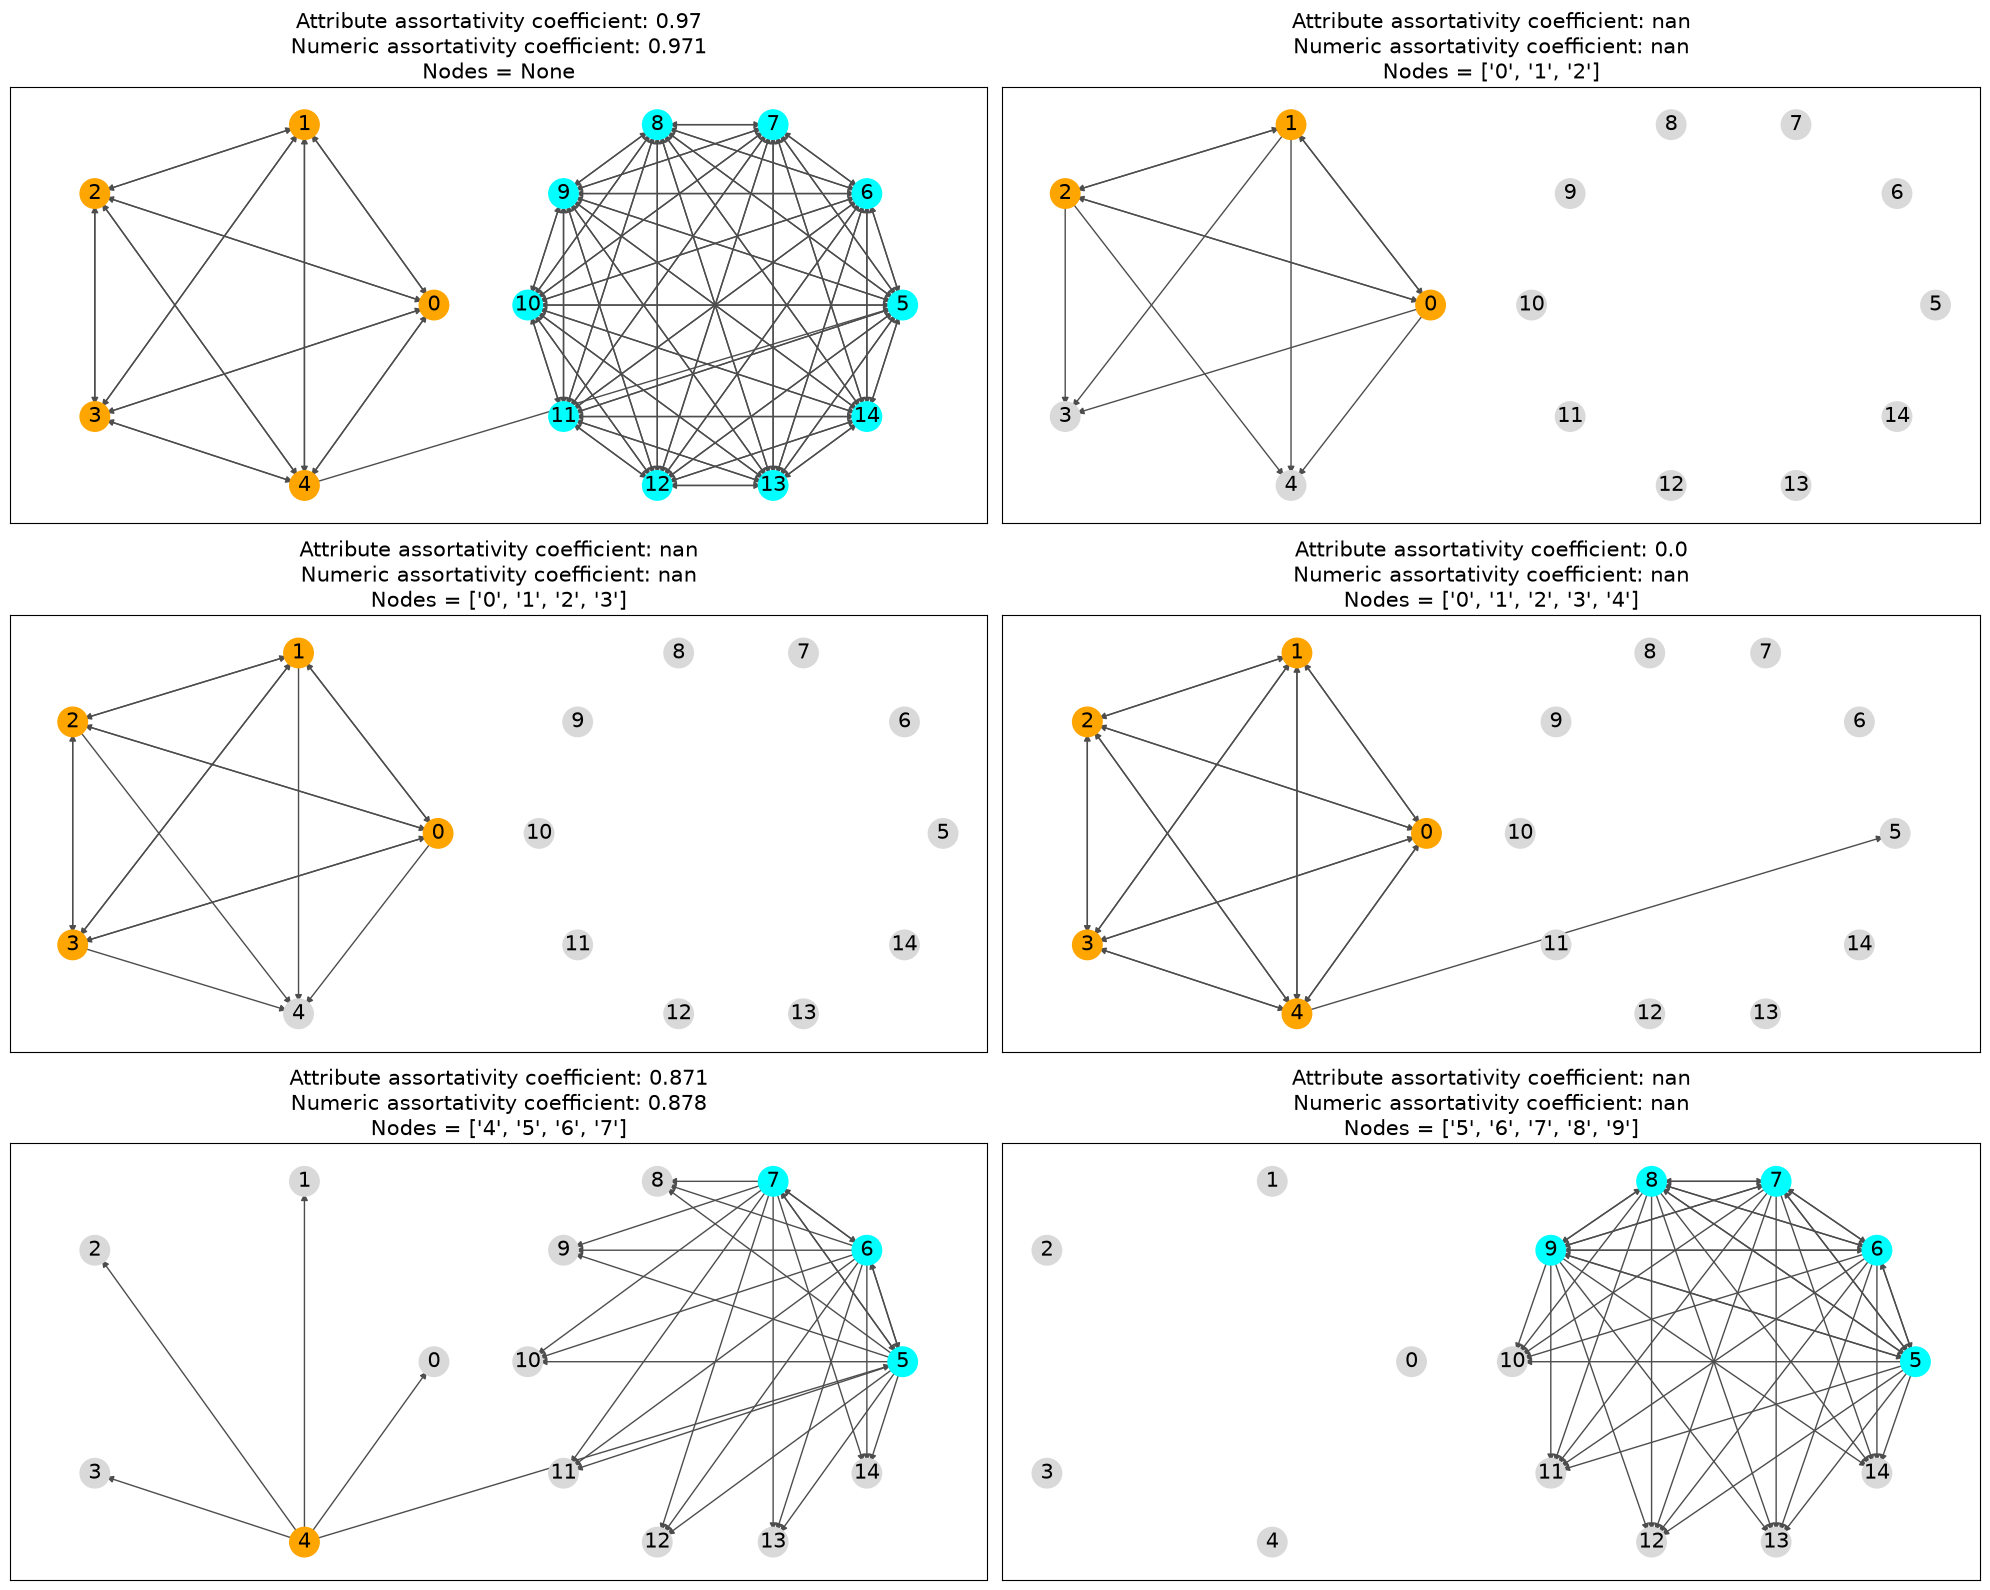

In [11]:
# En este otro ejemplo, solo los nodos considerados están coloreados y el resto en gris. Solo las aristas consideradas se dibujan. Copiado y pegado.
# list of nodes to consider for the i'th network in the example
# Note: passing 'None' means to consider all the nodes
nodes_list = [
    None,
    [str(i) for i in range(3)],
    [str(i) for i in range(4)],
    [str(i) for i in range(5)],
    [str(i) for i in range(4, 8)],
    [str(i) for i in range(5, 10)],
]
fig, axes = plt.subplots(3, 2, figsize=(20, 16))


def color_node(u, nodes):
    """Utility function to give the color of a node based on its attribute"""
    if u not in nodes:
        return "0.85"
    if G.nodes[u]["cluster"] == "K5":
        return "orange"
    else:
        return "cyan"


# adding a edge to show edge cases
G.add_edge("4", "5")

for nodes, ax in zip(nodes_list, axes.ravel()):
    # calculating the value of assortativity
    cr = nx.attribute_assortativity_coefficient(G, "cluster", nodes=nodes)
    nr = nx.numeric_assortativity_coefficient(G, "num_prop", nodes=nodes)

    # drawing network
    ax.set_title(
        f"Attribute assortativity coefficient: {cr:.3}\nNumeric assortativity coefficient: {nr:.3}\nNodes = {nodes}",
        size=15,
    )
    if nodes is None:
        nodes = [u for u in G.nodes()]
    node_colors = [color_node(u, nodes) for u in G.nodes]
    nx.draw_networkx_nodes(G, pos=pos, node_size=450, ax=ax, node_color=node_colors)
    nx.draw_networkx_labels(G, pos, labels={u: u for u in G.nodes}, font_size=15, ax=ax)
    nx.draw_networkx_edges(
        G,
        pos=pos,
        edgelist=[(u, v) for u, v in G.edges if u in nodes],
        ax=ax,
        edge_color="0.3",
    )
fig.tight_layout()